# Streamflow Prediction with LSTM (Upper Colorado Basin)

This notebook consolidates the full CVEN 6920 Assignment 3 workflow into a single reproducible document. It downloads USGS and Daymet data, builds site-level feature tables, trains an LSTM on three gauges, evaluates performance on a fully unseen gauge, and writes the same figures and summary outputs used elsewhere in the repository.

## Dependencies
Install the environment from `requirements.txt` or `environment.yml` before running this notebook. Internet access is required because USGS NWIS and Daymet data are retrieved programmatically.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from dataretrieval import nwis
from pydaymet import get_bycoords
from shapely.geometry import box
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
@dataclass(frozen=True)
class SiteConfig:
    site_no: str
    name: str
    role: str
    rationale: str


@dataclass
class Config:
    start_date: str = '2001-01-01'
    end_date: str = '2020-12-31'
    window: int = 30
    batch_size: int = 64
    hidden_size: int = 64
    num_layers: int = 2
    dropout: float = 0.2
    learning_rate: float = 1e-3
    epochs: int = 80
    patience: int = 10
    seed: int = 42
    output_dir: Path = Path('outputs')
    sites: Tuple[SiteConfig, ...] = (
        SiteConfig(
            site_no='09085000',
            name='Colorado River at Radium, CO',
            role='train',
            rationale='Upper mainstem/headwater-influenced site with strong snowmelt seasonality.',
        ),
        SiteConfig(
            site_no='09095500',
            name='Colorado River near Cameo, CO',
            role='train',
            rationale='Larger downstream mainstem integrator in the Upper Colorado Basin.',
        ),
        SiteConfig(
            site_no='09107000',
            name='Dolores River at Dolores, CO',
            role='train',
            rationale='Tributary basin with distinct runoff timing relative to mainstem gauges.',
        ),
        SiteConfig(
            site_no='09070500',
            name='Blue River below Green Mountain Reservoir, CO',
            role='test',
            rationale='Below-dam tributary site withheld entirely from training to assess transferability.',
        ),
    )


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


def nse(observed: np.ndarray, predicted: np.ndarray) -> float:
    denom = np.sum((observed - np.mean(observed)) ** 2)
    if denom == 0:
        return np.nan
    return 1 - (np.sum((observed - predicted) ** 2) / denom)


def kge(observed: np.ndarray, predicted: np.ndarray) -> float:
    obs = np.asarray(observed)
    sim = np.asarray(predicted)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return np.nan

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim, ddof=1) / (np.std(obs, ddof=1) + 1e-12)
    beta = np.mean(sim) / (np.mean(obs) + 1e-12)
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

In [3]:
def fetch_site_info(site_no: str) -> Dict[str, float]:
    info, _ = nwis.get_info(sites=site_no)
    row = info.iloc[0]
    return {
        'lat': float(row['dec_lat_va']),
        'lon': float(row['dec_long_va']),
        'elev_m': float(row['alt_va']) if pd.notna(row['alt_va']) else np.nan,
        'drain_area_sqmi': float(row['drain_area_va']) if pd.notna(row['drain_area_va']) else np.nan,
    }


def fetch_streamflow(site_no: str, start_date: str, end_date: str) -> pd.DataFrame:
    q = nwis.get_record(
        sites=site_no,
        service='dv',
        start=start_date,
        end=end_date,
        parameterCd='00060',
    )
    if q.empty:
        raise ValueError(f'No streamflow records for site {site_no}.')

    value_col = None
    for col in q.columns:
        if '00060' in col and 'Mean' in col:
            value_col = col
            break
    if value_col is None:
        candidates = [c for c in q.columns if '00060' in c]
        if not candidates:
            raise ValueError(f'Could not locate streamflow column for site {site_no}.')
        value_col = candidates[0]

    out = q[[value_col]].copy()
    out.columns = ['streamflow_cfs']
    out.index = pd.to_datetime(out.index)
    if getattr(out.index, 'tz', None) is not None:
        out.index = out.index.tz_localize(None)
    return out.sort_index()


def fetch_daymet_for_site(lat: float, lon: float, start_date: str, end_date: str) -> pd.DataFrame:
    ds = get_bycoords(
        (lon, lat),
        dates=(start_date, end_date),
        variables=('prcp', 'tmin', 'tmax', 'srad', 'vp', 'swe', 'dayl'),
    )

    if isinstance(ds, pd.DataFrame):
        met = ds.reset_index()
    else:
        met = ds.to_dataframe().reset_index()

    rename_map: Dict[str, str] = {}
    for col in met.columns:
        low = str(col).lower()
        if low.startswith('prcp'):
            rename_map[col] = 'prcp'
        elif low.startswith('tmin'):
            rename_map[col] = 'tmin'
        elif low.startswith('tmax'):
            rename_map[col] = 'tmax'
        elif low.startswith('srad'):
            rename_map[col] = 'srad'
        elif low.startswith('vp'):
            rename_map[col] = 'vp'
        elif low.startswith('swe'):
            rename_map[col] = 'swe'
        elif low.startswith('dayl'):
            rename_map[col] = 'dayl'
    met = met.rename(columns=rename_map)

    if 'time' in met.columns:
        met['date'] = pd.to_datetime(met['time'])
    elif 'date' in met.columns:
        met['date'] = pd.to_datetime(met['date'])
    else:
        met['date'] = pd.to_datetime(met.index)

    keep = ['date', 'prcp', 'tmin', 'tmax', 'srad', 'vp', 'swe', 'dayl']
    missing = [c for c in keep if c != 'date' and c not in met.columns]
    if missing:
        raise ValueError(f'Missing Daymet variables: {missing}')

    met = met[keep].copy()
    met = met.set_index('date').sort_index()
    met = met.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)]
    if getattr(met.index, 'tz', None) is not None:
        met.index = met.index.tz_localize(None)
    return met


def build_site_dataframe(site: SiteConfig, cfg: Config, meta: Dict[str, float] | None = None) -> pd.DataFrame:
    if meta is None:
        meta = fetch_site_info(site.site_no)
    q = fetch_streamflow(site.site_no, cfg.start_date, cfg.end_date)
    met = fetch_daymet_for_site(meta['lat'], meta['lon'], cfg.start_date, cfg.end_date)

    df = q.join(met, how='inner')
    df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
    df['elev_m'] = meta['elev_m']
    df['drain_area_sqmi'] = meta['drain_area_sqmi']
    df['target_log_q'] = np.log1p(df['streamflow_cfs'])
    return df.replace([np.inf, -np.inf], np.nan).dropna()

In [4]:
def create_sequences(
    df: pd.DataFrame, feature_cols: List[str], target_col: str, window: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = df[feature_cols].values
    y = df[target_col].values
    dates = df.index.values

    xs, ys, dts = [], [], []
    for i in range(window, len(df)):
        xs.append(x[i - window:i])
        ys.append(y[i])
        dts.append(dates[i])

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32), np.array(dts)


class LSTMRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_timestep = out[:, -1, :]
        pred = self.fc(last_timestep)
        return pred.squeeze(-1)


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float,
    epochs: int,
    patience: int,
    device: torch.device,
) -> Tuple[nn.Module, List[float], List[float]]:
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = np.inf
    wait = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)

        train_loss = running / len(train_loader.dataset)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_running += loss.item() * xb.size(0)

        val_loss = val_running / len(val_loader.dataset)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f'Epoch {epoch:03d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}')

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping triggered.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


def predict(model: nn.Module, x: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(x, dtype=torch.float32, device=device)
        return model(xb).cpu().numpy()

In [5]:
def plot_site_map_with_conus_inset(site_meta: pd.DataFrame, output_path: Path) -> None:
    us_states_url = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
    states = gpd.read_file(us_states_url).to_crs(epsg=4326)
    conus = states[~states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1.0], wspace=0.08)
    ax = fig.add_subplot(gs[0, 0])
    inset = fig.add_subplot(gs[0, 1])

    train_df = site_meta[site_meta['role'] == 'train']
    test_df = site_meta[site_meta['role'] == 'test']

    colorado = conus[conus['name'] == 'Colorado']
    neighbor_names = ['Utah', 'Wyoming', 'New Mexico', 'Arizona', 'Nebraska', 'Kansas', 'Oklahoma', 'Idaho']
    neighbors = conus[conus['name'].isin(neighbor_names)]

    main_lon_min, main_lon_max = -114.5, -101.0
    main_lat_min, main_lat_max = 35.0, 43.9
    ax.set_xlim(main_lon_min, main_lon_max)
    ax.set_ylim(main_lat_min, main_lat_max)

    try:
        cx.add_basemap(
            ax,
            crs='EPSG:4326',
            source=cx.providers.Esri.WorldTopoMap,
            alpha=0.9,
            attribution_size=6,
            zorder=0,
        )
    except Exception:
        pass

    conus.boundary.plot(ax=ax, color='#6f6f6f', linewidth=0.6, zorder=1)
    if not neighbors.empty:
        neighbors.boundary.plot(ax=ax, color='#444444', linewidth=1.0, zorder=2)
    if not colorado.empty:
        colorado.plot(ax=ax, facecolor='#f6e05e', edgecolor='#202020', linewidth=1.6, alpha=0.35, zorder=2)
        colorado.boundary.plot(ax=ax, color='#202020', linewidth=1.8, zorder=3)

    ax.scatter(train_df['lon'], train_df['lat'], s=95, c='#0b5fa5', marker='o', edgecolor='white', linewidth=0.8, label='Training sites', zorder=4)
    ax.scatter(test_df['lon'], test_df['lat'], s=150, c='#d62728', marker='*', edgecolor='white', linewidth=0.9, label='Unseen test site', zorder=5)

    for _, row in site_meta.iterrows():
        ax.text(
            row['lon'] + 0.1,
            row['lat'] + 0.06,
            row['site_no'],
            fontsize=9,
            color='#111111',
            bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1.5},
            zorder=6,
        )

    label_states = conus[conus['name'].isin(['Colorado', 'Utah', 'Wyoming', 'New Mexico', 'Arizona'])]
    for _, srow in label_states.iterrows():
        centroid = srow.geometry.centroid
        if main_lon_min <= centroid.x <= main_lon_max and main_lat_min <= centroid.y <= main_lat_max:
            ax.text(centroid.x, centroid.y, srow['name'], fontsize=8, color='#2a2a2a', ha='center', va='center', zorder=2)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Upper Colorado Sites with State-Level Geographic Context')
    ax.grid(alpha=0.25)
    ax.legend(loc='lower left')

    inset.set_xlim(-125.0, -66.5)
    inset.set_ylim(24.0, 49.5)
    conus.plot(ax=inset, facecolor='#f5f5f5', edgecolor='#9a9a9a', linewidth=0.5, zorder=1)

    try:
        cx.add_basemap(
            inset,
            crs='EPSG:4326',
            source=cx.providers.CartoDB.PositronNoLabels,
            alpha=0.55,
            attribution=False,
            zorder=0,
        )
    except Exception:
        pass

    study_box = gpd.GeoSeries([box(main_lon_min, main_lat_min, main_lon_max, main_lat_max)], crs='EPSG:4326')
    study_box.boundary.plot(ax=inset, color='#d62728', linewidth=1.6, zorder=3)
    inset.scatter(site_meta['lon'], site_meta['lat'], s=20, c='#0b5fa5', alpha=0.95, zorder=4)
    inset.set_title('CONUS Locator', fontsize=10)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.grid(alpha=0.15)

    fig.subplots_adjust(bottom=0.08, top=0.92, left=0.06, right=0.98)
    fig.savefig(output_path, dpi=250)
    plt.close(fig)

## Run Full Workflow
The next cell executes the complete assignment pipeline and writes outputs to the `outputs/` directory.

Building datasets for selected Upper Colorado Basin gauges...
  - 09085000: Colorado River at Radium, CO
  - 09095500: Colorado River near Cameo, CO
  - 09107000: Dolores River at Dolores, CO
  - 09070500: Blue River below Green Mountain Reservoir, CO
Training LSTM model...
Epoch 001 | train_loss=0.11360 | val_loss=0.04619
Epoch 002 | train_loss=0.03142 | val_loss=0.03959
Epoch 003 | train_loss=0.02930 | val_loss=0.04224
Epoch 004 | train_loss=0.02842 | val_loss=0.03559
Epoch 005 | train_loss=0.02615 | val_loss=0.03931
Epoch 006 | train_loss=0.02601 | val_loss=0.03612
Epoch 007 | train_loss=0.02383 | val_loss=0.03584
Epoch 008 | train_loss=0.02387 | val_loss=0.03754
Epoch 009 | train_loss=0.02229 | val_loss=0.04012
Epoch 010 | train_loss=0.02144 | val_loss=0.03801
Epoch 011 | train_loss=0.02031 | val_loss=0.03534
Epoch 012 | train_loss=0.01914 | val_loss=0.03898
Epoch 013 | train_loss=0.01866 | val_loss=0.04269
Epoch 014 | train_loss=0.01730 | val_loss=0.04020
Epoch 015 | train_loss=0.

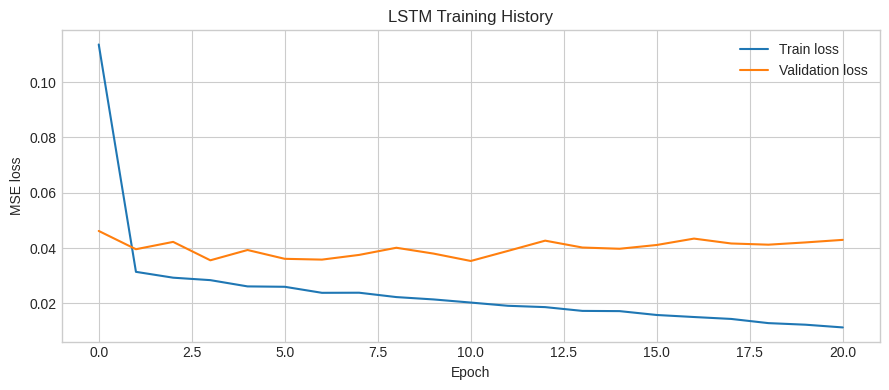

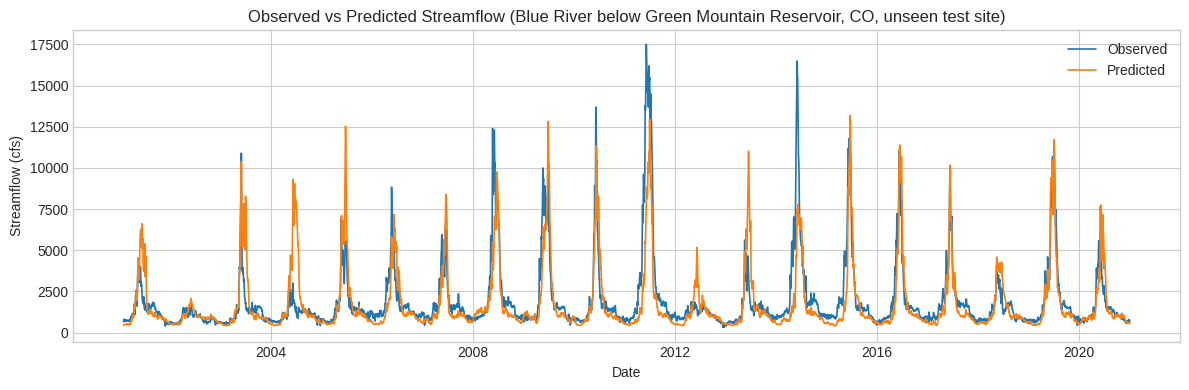

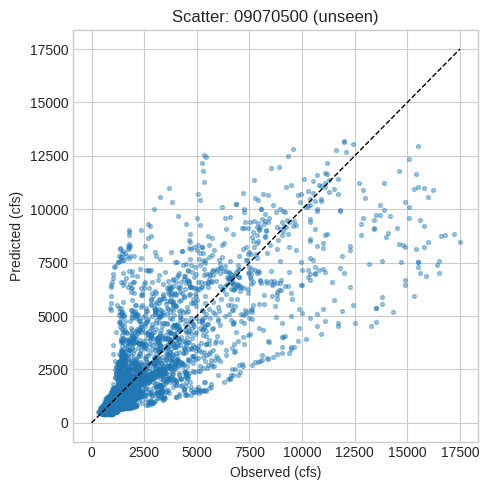

,site_no,site_name,role,rmse_cfs,mae_cfs,nse,kge,samples
0,09085000,"Colorado River at Radium, CO",train,422.172395,214.372253,0.868151,0.805574,7270
1,09095500,"Colorado River near Cameo, CO",train,1517.742073,763.687561,0.837976,0.837708,7270
2,09107000,"Dolores River at Dolores, CO",train,55.436082,23.575367,0.820315,0.860457,7270
3,09070500,"Blue River below Green Mountain Reservoir, CO",test,1297.436896,666.826355,0.646445,0.790994,7270


In [6]:
cfg = Config()
set_seed(cfg.seed)
ensure_dir(cfg.output_dir)
ensure_dir(cfg.output_dir / 'prepared_dataframes')

train_sites = [s for s in cfg.sites if s.role == 'train']
test_site = [s for s in cfg.sites if s.role == 'test'][0]

print('Building datasets for selected Upper Colorado Basin gauges...')
site_frames: Dict[str, pd.DataFrame] = {}
site_meta_rows = []
prepared_dir = cfg.output_dir / 'prepared_dataframes'

for site in cfg.sites:
    print(f'  - {site.site_no}: {site.name}')
    meta = fetch_site_info(site.site_no)
    prepared_path = prepared_dir / f'site_dataframe_{site.site_no}.csv'

    if prepared_path.exists():
        df = pd.read_csv(prepared_path, parse_dates=['date']).set_index('date')
    else:
        df = build_site_dataframe(site, cfg, meta=meta)
        df.reset_index().rename(columns={'index': 'date'}).to_csv(prepared_path, index=False)

    site_frames[site.site_no] = df
    site_meta_rows.append({
        'site_no': site.site_no,
        'site_name': site.name,
        'role': site.role,
        'rationale': site.rationale,
        'lat': meta['lat'],
        'lon': meta['lon'],
        'records': len(df),
        'start': str(df.index.min().date()),
        'end': str(df.index.max().date()),
    })

site_meta = pd.DataFrame(site_meta_rows)
site_meta.to_csv(cfg.output_dir / 'site_selection_summary.csv', index=False)
plot_site_map_with_conus_inset(site_meta, cfg.output_dir / 'study_sites_map_conus_inset.png')

feature_cols = [
    'prcp', 'tmin', 'tmax', 'srad', 'vp', 'swe', 'dayl',
    'doy_sin', 'doy_cos', 'elev_m', 'drain_area_sqmi',
]
target_col = 'target_log_q'

train_concat = pd.concat([site_frames[s.site_no] for s in train_sites], axis=0).sort_index()
x_scaler = StandardScaler()
y_scaler = StandardScaler()
x_scaler.fit(train_concat[feature_cols])
y_scaler.fit(train_concat[[target_col]])

for site_no, frame in site_frames.items():
    site_frames[site_no][feature_cols] = x_scaler.transform(frame[feature_cols])
    site_frames[site_no][target_col] = y_scaler.transform(frame[[target_col]])

x_train_all, y_train_all = [], []
for site in train_sites:
    x_site, y_site, _ = create_sequences(site_frames[site.site_no], feature_cols, target_col, cfg.window)
    x_train_all.append(x_site)
    y_train_all.append(y_site)

x_train = np.concatenate(x_train_all, axis=0)
y_train = np.concatenate(y_train_all, axis=0)
split_idx = int(0.8 * len(x_train))
x_tr, y_tr = x_train[:split_idx], y_train[:split_idx]
x_val, y_val = x_train[split_idx:], y_train[split_idx:]
x_test, y_test, test_dates = create_sequences(site_frames[test_site.site_no], feature_cols, target_col, cfg.window)

train_loader = DataLoader(TensorDataset(torch.tensor(x_tr), torch.tensor(y_tr)), batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(x_val), torch.tensor(y_val)), batch_size=cfg.batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMRegressor(
    input_size=len(feature_cols),
    hidden_size=cfg.hidden_size,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
).to(device)

print('Training LSTM model...')
model, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    lr=cfg.learning_rate,
    epochs=cfg.epochs,
    patience=cfg.patience,
    device=device,
)

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('LSTM Training History')
plt.legend()
plt.tight_layout()
plt.savefig(cfg.output_dir / 'training_history.png', dpi=200)
plt.show()
plt.close()

y_test_pred_scaled = predict(model, x_test, device)
y_test_pred_log = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()
y_test_obs_log = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_test_pred = np.expm1(y_test_pred_log)
y_test_obs = np.expm1(y_test_obs_log)

perf_rows = []
prediction_frames = {}
for site in cfg.sites:
    x_site, y_site, d_site = create_sequences(site_frames[site.site_no], feature_cols, target_col, cfg.window)
    pred_scaled = predict(model, x_site, device)
    pred_log = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    obs_log = y_scaler.inverse_transform(y_site.reshape(-1, 1)).ravel()
    pred = np.expm1(pred_log)
    obs = np.expm1(obs_log)

    perf_rows.append({
        'site_no': site.site_no,
        'site_name': site.name,
        'role': site.role,
        'rmse_cfs': float(np.sqrt(mean_squared_error(obs, pred))),
        'mae_cfs': float(mean_absolute_error(obs, pred)),
        'nse': float(nse(obs, pred)),
        'kge': float(kge(obs, pred)),
        'samples': int(len(obs)),
    })

    if site.role == 'test':
        pred_df = pd.DataFrame({
            'date': pd.to_datetime(d_site),
            'observed_cfs': obs,
            'predicted_cfs': pred,
        }).sort_values('date')
        prediction_frames[site.site_no] = pred_df
        pred_df.to_csv(cfg.output_dir / f'predictions_{site.site_no}.csv', index=False)

        plt.figure(figsize=(12, 4))
        plt.plot(pred_df['date'], pred_df['observed_cfs'], label='Observed', linewidth=1.2)
        plt.plot(pred_df['date'], pred_df['predicted_cfs'], label='Predicted', linewidth=1.2)
        plt.xlabel('Date')
        plt.ylabel('Streamflow (cfs)')
        plt.title(f'Observed vs Predicted Streamflow ({site.name}, unseen test site)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(cfg.output_dir / f'obs_vs_pred_timeseries_{site.site_no}.png', dpi=220)
        plt.show()
        plt.close()

        plt.figure(figsize=(5, 5))
        plt.scatter(pred_df['observed_cfs'], pred_df['predicted_cfs'], s=8, alpha=0.4)
        max_q = max(pred_df['observed_cfs'].max(), pred_df['predicted_cfs'].max())
        plt.plot([0, max_q], [0, max_q], 'k--', linewidth=1)
        plt.xlabel('Observed (cfs)')
        plt.ylabel('Predicted (cfs)')
        plt.title(f'Scatter: {site.site_no} (unseen)')
        plt.tight_layout()
        plt.savefig(cfg.output_dir / f'obs_vs_pred_scatter_{site.site_no}.png', dpi=220)
        plt.show()
        plt.close()

perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv(cfg.output_dir / 'performance_summary_by_site.csv', index=False)

test_row = perf_df.loc[perf_df['role'] == 'test'].iloc[0]
summary_text = [
    'Option 2: Streamflow Prediction with LSTM',
    '',
    'Unseen-site evaluation:',
    f"  Site: {test_row['site_no']} ({test_row['site_name']})",
    f"  RMSE: {test_row['rmse_cfs']:.3f} cfs",
    f"  MAE : {test_row['mae_cfs']:.3f} cfs",
    f"  NSE : {test_row['nse']:.3f}",
    f"  KGE : {test_row['kge']:.3f}",
    '',
    'Model architecture:',
    f"  LSTM(input={len(feature_cols)}, hidden={cfg.hidden_size}, layers={cfg.num_layers}, dropout={cfg.dropout})",
    '  Dense(hidden/2, ReLU) -> Dense(1)',
]
(cfg.output_dir / 'run_summary.txt').write_text('\n'.join(summary_text), encoding='utf-8')
(cfg.output_dir / 'analysis_summary.txt').write_text(
    '\n'.join([
        'CVEN 6920 Assignment 3 - Figure/Analysis Summary',
        '',
        f"Test site: {test_row['site_no']} ({test_row['site_name']})",
        f"NSE: {test_row['nse']:.3f}",
        f"KGE: {test_row['kge']:.3f}",
        f"RMSE (cfs): {test_row['rmse_cfs']:.3f}",
        f"MAE (cfs): {test_row['mae_cfs']:.3f}",
        '',
        'Key figures:',
        '- outputs/study_sites_map_conus_inset.png',
        '- outputs/training_history.png',
        '- outputs/obs_vs_pred_timeseries_09070500.png',
        '- outputs/obs_vs_pred_scatter_09070500.png',
    ]),
    encoding='utf-8',
)

perf_df

In [7]:
site_meta

,site_no,site_name,role,rationale,lat,lon,records,start,end
0,09085000,"Colorado River at Radium, CO",train,Upper mainstem/headwater-influenced site with ...,39.546667,-107.330833,7300,2001-01-01,2020-12-30
1,09095500,"Colorado River near Cameo, CO",train,Larger downstream mainstem integrator in the U...,39.239146,-108.266195,7300,2001-01-01,2020-12-30
2,09107000,"Dolores River at Dolores, CO",train,Tributary basin with distinct runoff timing re...,38.860271,-106.566697,7300,2001-01-01,2020-12-30
3,09070500,"Blue River below Green Mountain Reservoir, CO",test,Below-dam tributary site withheld entirely fro...,39.644611,-107.078014,7300,2001-01-01,2020-12-30
